# Introdução
O naufrágio do RMS Titanic, em 1912, é um dos desastres mais famosos da história. Durante sua primeira viagem, o navio bateu em um iceberg no Oceano Atlântico Norte e afundou, causando a morte de muitos passageiros e tripulantes.

**Objetivo**

Identificar e analisar os principais fatores que influenciaram a sobrevivência dos passageiros do Titanic utilizando  Análise Exploratória de Dados (EDA) a partir do conjunto de dados do Titanic.



# Importação e carregamento dos dados

Neste projeto, são utilizadas bibliotecas para manipular, analisar e visualizar os dados.
O Pandas é usado para trabalhar com o dataset, o NumPy para cálculos numéricos, e o Matplotlib junto com o Seaborn para criar gráficos durante a análise.

 O conjunto de dados é obtido por meio de um link fornecido pelo curso, sendo enviado para o GitHub, organizado em uma pasta e acessado pelo seu caminho.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/evelynkleinenf-cloud/titanic_eda/main/titanic_dataset.csv"
df_original = pd.read_csv(url)
df = df_original.copy()
df.head()

 O dataset do Titanic contém informações sobre os passageiros que estavam no navio em 1912.
Cada linha representa um passageiro, e cada coluna traz uma característica, como idade, sexo, classe e porto de embarque.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


PassengerId: identificador único de cada passageiro


Survived: indica se sobreviveu (0 = não, 1 = sim)


Pclass: classe da passagem (1 = primeira, 2 = segunda, 3 = terceira)


Name: nome do passageiro


Sex: sexo


Age: idade


SibSp: número de irmãos ou cônjuges a bordo


Parch: número de pais ou filhos a bordo


Ticket: número do ticket


Fare: valor da passagem


Cabin: número da cabine


Embarked: porto de embarque


C = Cherbourg


Q = Queenstown


S = Southampton



Após entender as variáveis, é possível escolher as mais importantes para a análise.
Assim, foram selecionadas apenas as colunas mais relevantes para estudar os fatores que influenciaram a sobrevivência, como classe, sexo, idade, número de familiares, valor da passagem e porto de embarque.
Essa escolha ajuda a simplificar o dataset e focar nas informações mais úteis para as próximas etapas de tratamento e análise dos dados.


In [ ]:
df_principais = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
df_principais.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# Limpeza de dados

Registros duplicados podem prejudicar a análise, pois representam a repetição de um mesmo dado.
Por isso, identificamos e removemos essas duplicações.
Com essa limpeza, o número de linhas foi reduzido de 891 para 780, garantindo que cada registro seja único e melhorando a qualidade dos dados.


In [ ]:
print(f"Linhas antes da remoção de duplicadas: {df_principais.shape[0]}")
df_principais_sem_duplicadas = df_principais.drop_duplicates().copy()
print(f"Linhas depois da remoção de duplicadas: {df_principais_sem_duplicadas.shape[0]}")

Número de linhas duplicadas no DataFrame df_principais: 111


 Valores ausentes podem atrapalhar a análise, principalmente em cálculos e gráficos.
Primeiro, identificamos onde esses valores estavam e depois definimos como tratá-los.
A coluna Age possui vários valores faltantes, e a coluna Embarked também tem alguns.
Para evitar perder muitos dados, os valores ausentes de Age foram substituídos pela mediana, e os de Embarked pela moda, já que é uma variável categórica.


In [ ]:
print('Valores nulos por coluna antes do tratamento(contagem):')
print(df_principais_sem_duplicadas.isnull().sum())
print('Valores nulos por coluna antes do tratamento(porcentagem):')
print(df_principais_sem_duplicadas.isnull().sum() / len(df_principais_sem_duplicadas) * 100)

Valores nulos por coluna antes do tratamento(contagem):
Survived      0
Pclass        0
Sex           0
Age         104
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
Valores nulos por coluna antes do tratamento(porcentagem):
Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         13.333333
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Embarked     0.256410
dtype: float64


In [ ]:
# Tratar Age: mediana
median_age = df_principais_sem_duplicadas['Age'].median()
df_principais_sem_duplicadas['Age'] = df_principais_sem_duplicadas['Age'].fillna(median_age)
print("Valores nulos em 'Age' preenchidos com a mediana:", median_age)

Valores nulos em 'Age' preenchidos com a mediana: 28.0


In [ ]:
# Tratar Embarked: moda
mode_embarked = df_principais_sem_duplicadas['Embarked'].mode()[0]
df_principais_sem_duplicadas['Embarked'] = df_principais_sem_duplicadas['Embarked'].fillna(mode_embarked)
print("Valores nulos em 'Embarked' preenchidos com a moda:", mode_embarked)

Valores nulos em 'Embarked' preenchidos com a moda: S


Também verificamos se os tipos de dados das colunas estavam corretos.
As variáveis Survived, Pclass, Sex e Embarked representam categorias, então foram convertidas para o tipo category.
Isso ajuda a organizar melhor os dados e facilita a análise e a criação de gráficos.


In [ ]:
df_principais_sem_duplicadas['Survived'] = df_principais_sem_duplicadas['Survived'].astype('category')
df_principais_sem_duplicadas['Pclass'] = df_principais_sem_duplicadas['Pclass'].astype('category')
df_principais_sem_duplicadas['Sex'] = df_principais_sem_duplicadas['Sex'].astype('category')
df_principais_sem_duplicadas['Embarked'] = df_principais_sem_duplicadas['Embarked'].astype('category')
print("DataFrame com tipagem atualizada:")
df_principais_sem_duplicadas.dtypes

DataFrame com tipagem atualizada:


,0
Survived,category
Pclass,category
Sex,category
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,category


Valores inconsistentes podem aparecer por erros de digitação ou registros incorretos.
Para verificar isso, analisamos os valores únicos das variáveis categóricas e os intervalos das variáveis numéricas.
As categorias estavam padronizadas, sem variações de escrita ou valores inesperados.
Nas variáveis numéricas, também não foram encontrados valores fora do esperado, como idades negativas ou números muito altos.
Isso indica que os dados estão consistentes.


In [ ]:
df_principais_sem_duplicadas[['Age','SibSp','Parch','Fare']].describe()

,Age,SibSp,Parch,Fare
count,780.000000,780.000000,780.000000,780.000000
mean,29.571051,0.525641,0.417949,34.829108
std,13.722689,0.988046,0.838536,52.263440
min,0.420000,0.000000,0.000000,0.000000
25%,21.750000,0.000000,0.000000,8.050000
50%,28.000000,0.000000,0.000000,15.950000
75%,36.000000,1.000000,1.000000,34.375000
max,80.000000,8.000000,6.000000,512.329200


## Feature Engineering

Criamos a variável TamanhoFamilia somando SibSp (irmãos/cônjuges) e Parch (pais/filhos), além do próprio passageiro.
Essa variável mostra quantas pessoas da família estavam no navio com o passageiro, permitindo analisar se isso influenciou na sobrevivência.


In [ ]:
df_principais_sem_duplicadas["TamanhoFamilia"] = df_principais_sem_duplicadas["SibSp"] + df_principais_sem_duplicadas["Parch"] + 1
df_principais_sem_duplicadas[['SibSp','Parch','TamanhoFamilia']].head()

,SibSp,Parch,TamanhoFamilia
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


 Após todas as etapas de limpeza, tratamento e criação de variáveis, verificamos se tudo foi feito corretamente.
Em seguida, organizamos os dados em um novo DataFrame, deixando o conjunto mais limpo e preparado para a análise exploratória.


In [ ]:
df_titanic = df_principais_sem_duplicadas.copy()
df_titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,TamanhoFamilia,PassSozinho,CategoriaFamilia,FaixaEtaria
0,0,3,male,22.0,1,0,7.2500,S,2,0,Familia pequena,JovemAdulto
1,1,1,female,38.0,1,0,71.2833,C,2,0,Familia pequena,Adulto
2,1,3,female,26.0,0,0,7.9250,S,1,1,Sozinho,JovemAdulto
3,1,1,female,35.0,1,0,53.1000,S,2,0,Familia pequena,JovemAdulto
4,0,3,male,35.0,0,0,8.0500,S,1,1,Sozinho,JovemAdulto


# Análise exploratória

## Sobrevivência Geral


 Antes de analisar fatores específicos, observamos a variável Survived, que indica quem sobreviveu (1) e quem não sobreviveu (0).
A análise mostra que a maioria dos passageiros não sobreviveu ao naufrágio.
Isso reforça a gravidade do desastre e mostra a importância de investigar quais fatores influenciaram a sobrevivência.


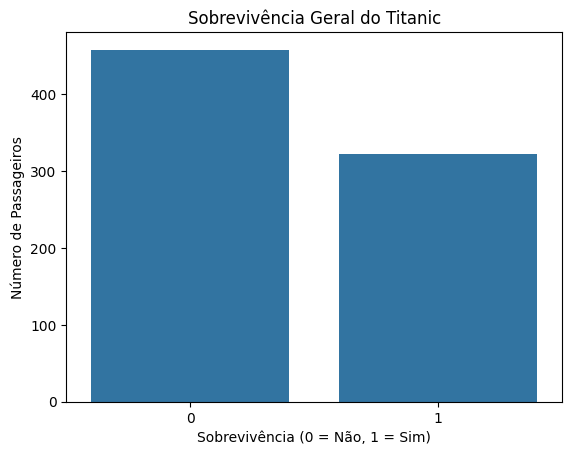

In [ ]:
# Visualização gráfica da sobrevivência
sns.countplot(x='Survived', data=df_titanic)
plt.title('Sobrevivência Geral do Titanic')
plt.xlabel('Sobrevivência (0 = Não, 1 = Sim)')
plt.ylabel('Número de Passageiros')
plt.show()

## Sobrevivência por Gênero

 O gênero pode ter sido um fator importante na sobrevivência, já que há relatos de que mulheres e crianças tiveram prioridade nos botes.
Os dados mostram uma grande diferença entre homens e mulheres: as mulheres tiveram uma taxa de sobrevivência muito maior.
Isso indica que o gênero foi um dos fatores mais relevantes, provavelmente por causa da prioridade no resgate.


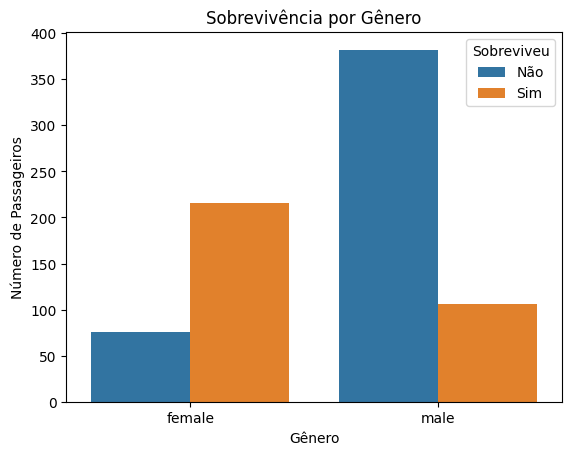

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

## Sobrevivência por Classe Social

 Os passageiros estavam divididos em três classes (Pclass), que também indicam nível socioeconômico.
A análise mostra que passageiros da primeira classe tiveram maior taxa de sobrevivência, enquanto os da terceira classe tiveram as menores.
Isso pode estar relacionado à localização no navio, acesso aos botes e prioridade no resgate. Passageiros de classes mais altas provavelmente tiveram mais facilidade para escapar.
Assim, a classe social também foi um fator importante.


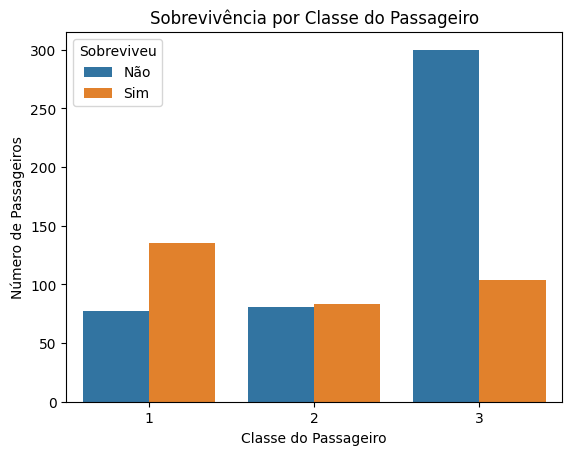

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Classe do Passageiro')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

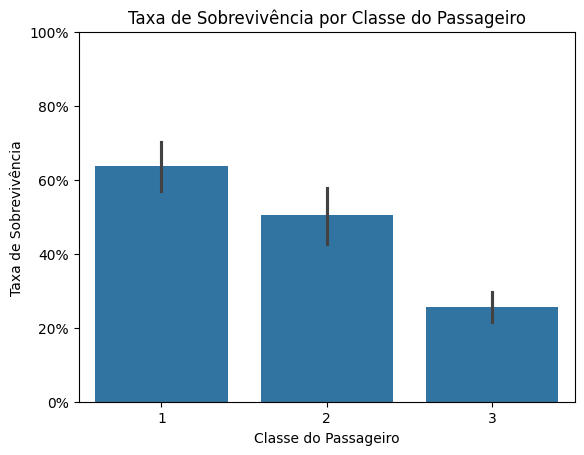

In [ ]:
from matplotlib.ticker import PercentFormatter
sns.barplot(x='Pclass', y='Survived', data=df_titanic, order=[1,2,3])
plt.title('Taxa de Sobrevivência por Classe do Passageiro')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

## Sobrevivência por Idade

 Em situações de emergência, crianças costumam ter prioridade, o que pode influenciar a sobrevivência.
Os dados indicam que crianças tiveram uma taxa de sobrevivência maior do que adultos.
Mesmo assim, pessoas de todas as idades foram afetadas, mostrando que a idade não foi o único fator importante.


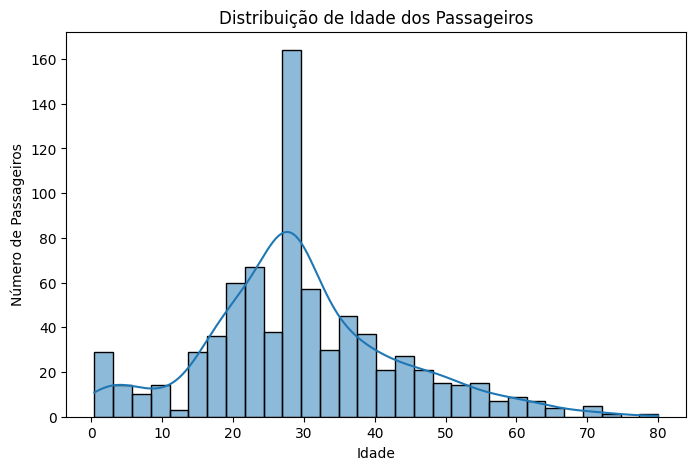

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_titanic, x='Age', bins=30,kde=True)
plt.title('Distribuição de Idade dos Passageiros')
plt.xlabel('Idade')
plt.ylabel('Número de Passageiros')
plt.show()

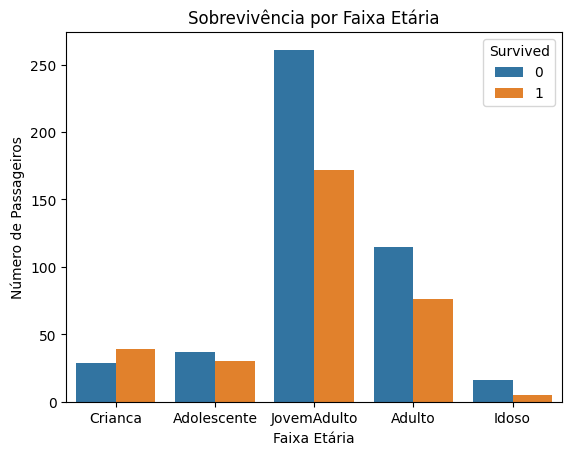

In [ ]:
sns.countplot(x='FaixaEtaria', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Passageiros')
plt.show()

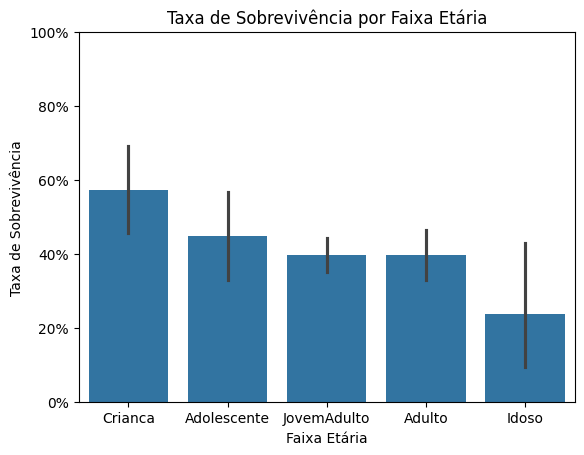

In [ ]:
from matplotlib.ticker import PercentFormatter
sns.barplot(x='FaixaEtaria', y='Survived', data=df_titanic)
plt.title('Taxa de Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

## Sobrevivência por Tamanho da Família vs Sozinhos

 O tamanho da família também pode influenciar.
Passageiros que estavam sozinhos ou com famílias muito grandes tiveram menores taxas de sobrevivência.
Já aqueles com famílias pequenas ou médias tiveram melhores chances.
Isso sugere que viajar com poucos familiares pode ter ajudado, talvez pelo apoio ou organização durante a evacuação.


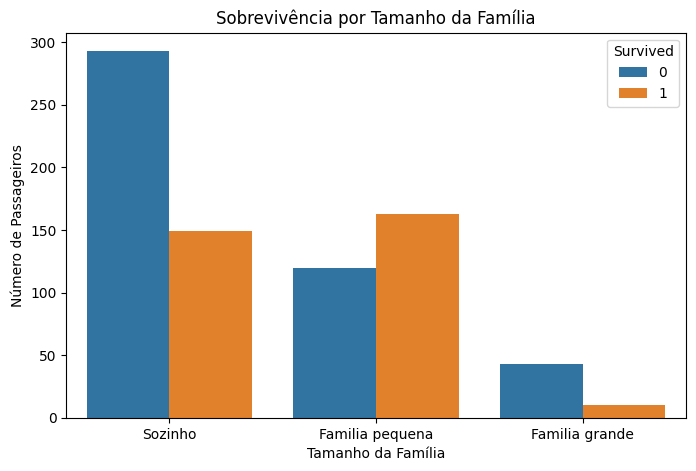

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='CategoriaFamilia', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Tamanho da Família')
plt.xlabel('Tamanho da Família')
plt.ylabel('Número de Passageiros')
plt.show()

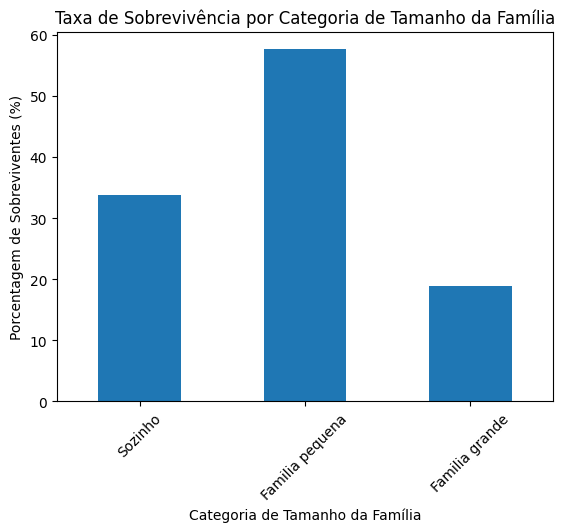

In [ ]:
taxa = df_titanic.groupby('CategoriaFamilia', observed=True)['Survived'].mean() * 100
taxa.plot(kind='bar')
plt.title('Taxa de Sobrevivência por Categoria de Tamanho da Família')
plt.xlabel('Categoria de Tamanho da Família')
plt.xticks(rotation=45)
plt.ylabel('Porcentagem de Sobreviventes (%)')
plt.show()

# Relações entre Variáveis **OPCIONAL**

## Sobrevivência por Gênero e Classe Social

 Essa análise mostra como gênero e classe social juntos influenciam a sobrevivência.
Os dados indicam que as mulheres tiveram maior taxa de sobrevivência em todas as classes.
Além disso, passageiros da primeira classe tiveram mais chances de sobreviver do que os das classes mais baixas.
Entre os homens, a sobrevivência foi bem menor, principalmente na terceira classe.


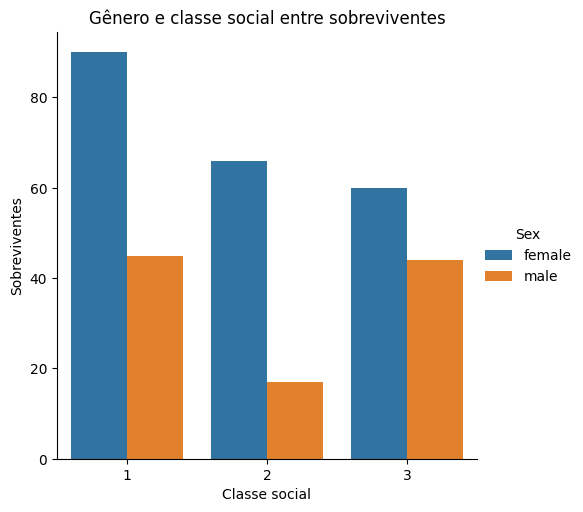

In [ ]:
sns.catplot(x='Pclass', hue='Sex', kind='count', data=df_titanic[df_titanic['Survived'] == 1])
plt.title('Gênero e classe social entre sobreviventes')
plt.xlabel('Classe social')
plt.ylabel('Sobreviventes')
plt.show()

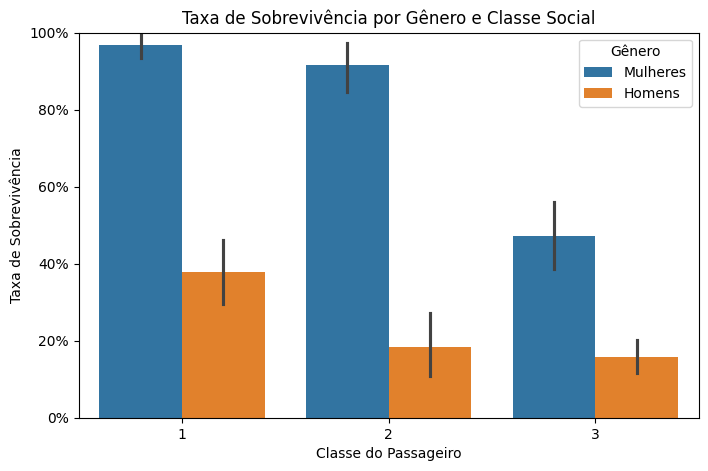

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df_titanic)
plt.title('Taxa de Sobrevivência por Gênero e Classe Social')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
handles, labels = ax.get_legend_handles_labels()
labels = ['Homens' if l=='male' else 'Mulheres' for l in labels]
ax.legend(handles, labels, title='Gênero')
plt.show()

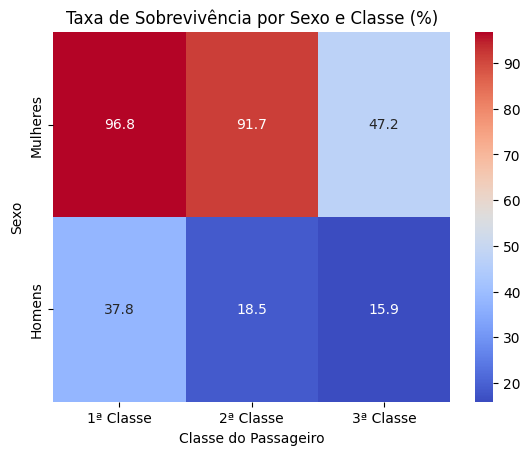

In [ ]:
tabela = df_titanic.pivot_table(values='Survived', index='Sex', columns='Pclass', observed=True)*100
tabela.index = ['Mulheres', 'Homens']
tabela.columns = ['1ª Classe', '2ª Classe', '3ª Classe']
sns.heatmap(tabela, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Taxa de Sobrevivência por Sexo e Classe (%)')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Sexo')
plt.show()


## Sobrevivência por Idade/Faixa Etária e Gênero

Aqui analisamos idade, gênero e sobrevivência ao mesmo tempo.
Os resultados mostram que crianças e mulheres tiveram maiores chances de sobreviver.
Isso reforça a ideia de que esses grupos tiveram prioridade durante o resgate.


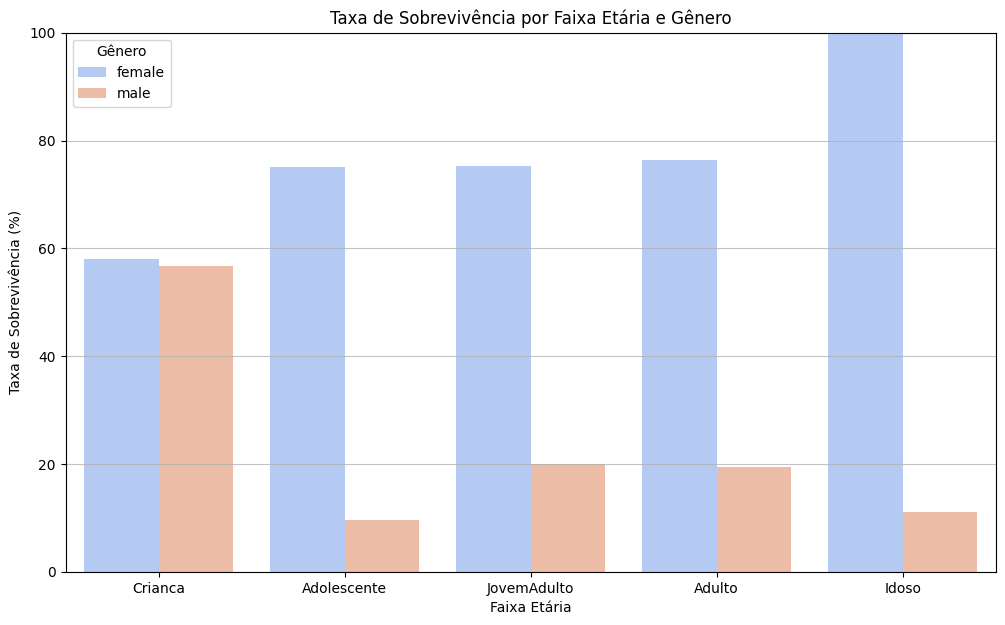

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='FaixaEtaria', y='Survived', hue='Sex', data=taxa_sobrevivencia_idade_sexo.reset_index(), palette='coolwarm')
plt.title('Taxa de Sobrevivência por Faixa Etária e Gênero')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.75)
plt.legend(title='Gênero')
plt.show()

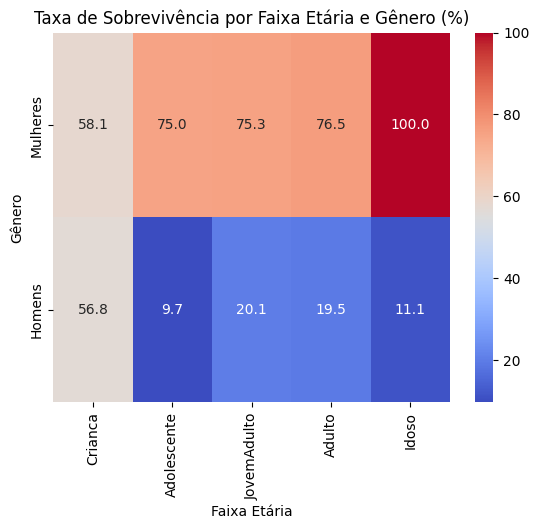

In [ ]:
tabela = df_titanic.pivot_table(values='Survived', index='Sex', columns='FaixaEtaria', observed=True) * 100
tabela.index = tabela.index.map({'male':'Homens', 'female':'Mulheres'})
sns.heatmap(tabela, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Taxa de Sobrevivência por Faixa Etária e Gênero (%)')
plt.xlabel('Faixa Etária')
plt.ylabel('Gênero')
plt.show()

# 8.Análise de Correlação **OPCIONAL**

Além dos gráficos, também analisamos a correlação entre variáveis numéricas.
A matriz de correlação mostra se existe relação entre as variáveis, com valores entre -1 e 1:
Próximo de 1: correlação positiva (as duas variáveis aumentam juntas)


Próximo de -1: correlação negativa (uma aumenta e a outra diminui)


Próximo de 0: pouca ou nenhuma relação


No gráfico (heatmap), cores mais vermelhas indicam correlação positiva e cores mais azuis indicam correlação negativa.

In [ ]:
# Variáveis numéricas relevantes
colunas = ['Survived','Age', 'SibSp', 'Parch','Fare','TamanhoFamilia','PassSozinho']
# Matriz de correlação
matriz_correlacao = df_titanic[colunas].corr()
print("Matriz de Correlação:")
display(matriz_correlacao)


Matriz de Correlação:


,Survived,Age,SibSp,Parch,Fare,TamanhoFamilia,PassSozinho
Survived,1.000000,-0.077843,-0.037597,0.069669,0.246669,0.013996,-0.175864
Age,-0.077843,1.000000,-0.278655,-0.182174,0.092566,-0.281656,0.189145
SibSp,-0.037597,-0.278655,1.000000,0.380596,0.134127,0.860061,-0.608756
Parch,0.069669,-0.182174,0.380596,1.000000,0.191055,0.799131,-0.570338
Fare,0.246669,0.092566,0.134127,0.191055,1.000000,0.192601,-0.245279
TamanhoFamilia,0.013996,-0.281656,0.860061,0.799131,0.192601,1.000000,-0.710404
PassSozinho,-0.175864,0.189145,-0.608756,-0.570338,-0.245279,-0.710404,1.000000


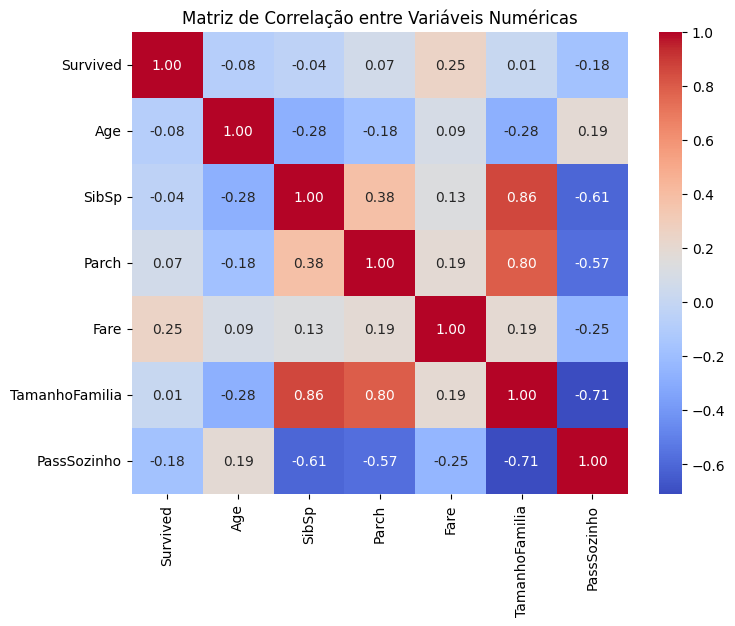

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

**Conclusão**

 A matriz de correlação mostra que as variáveis relacionadas à família têm forte relação entre si. Porém, as variáveis numéricas, no geral, têm pouca ligação direta com a sobrevivência.
Entre elas, a variável Fare foi a que mais se destacou, com relação positiva. Isso indica que passageiros que pagaram mais pela passagem tiveram maior chance de sobreviver.


# Principais Insights da Análise


*   **Gênero** foi o fator mais importante

*   **Classe social** teve grande impacto


*   Crianças tiveram maior sobrevivência

*   Passageiros da 1ª classe tiveram vantagem

**Conclusão**

 Os principais fatores de sobrevivência no desastre do Titanic foram gênero, classe social e idade. Mulheres e passageiros da primeira classe tiveram mais chances de sobreviver, enquanto homens da terceira classe tiveram as menores.

Esses resultados mostram como a análise de dados pode ajudar a entender melhor eventos históricos e identificar padrões importantes, que podem contribuir para melhorar decisões e prevenir situações semelhantes no futuro.

**OPCIONAL**

## Influência do gênero

 O gênero foi um dos fatores mais importantes. Mulheres tiveram uma taxa de sobrevivência bem maior do que homens.
Isso está de acordo com os registros históricos, que indicam prioridade para mulheres e crianças nos botes salva-vidas.


## Influência da classe social

 A classe da passagem também teve grande impacto.
Passageiros da primeira classe tiveram mais chances de sobreviver, enquanto os da terceira classe tiveram as menores taxas.
Isso pode estar ligado à localização no navio e ao acesso aos botes.

## Influência da idade

 A idade também teve influência.
Crianças tiveram maior taxa de sobrevivência em comparação com adultos, o que reforça a ideia de prioridade durante o resgate.

## Influência do preço da passagem

 Passageiros que pagaram mais caro pelas passagens tiveram maiores chances de sobreviver.
Como o valor da passagem está relacionado à classe social, esse resultado confirma a influência da classe na sobrevivência.

## Influência do tamanho da família

 O tamanho da família também teve impacto.
Quem viajava sozinho ou em famílias muito grandes teve menores chances de sobreviver.
Já passageiros com famílias pequenas tiveram resultados melhores, possivelmente por apoio entre familiares ou melhor organização na evacuação.

## Influência do porto de embarque

 Também foram observadas diferenças entre os portos de embarque.
Passageiros que embarcaram em Cherbourg tiveram maior taxa de sobrevivência, possivelmente porque havia mais passageiros de classe alta nesse grupo.

